# **Mount** Google Drive

In [11]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset** Extraction

In [13]:
import zipfile

# Extract Dataset from Drive
zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/medical_mnist"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [15]:
import os
os.listdir(extract_path)

['HeadCT', 'BreastMRI', 'ChestCT', 'AbdomenCT', 'CXR', 'Hand']

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# **Data** Loading using tf.data

In [18]:
LOCAL_DATA_DIR = "/content/medical_mnist"
DATA_DIR = str(LOCAL_DATA_DIR)

IMG_SIZE = (64, 64)
BATCH_SIZE = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 58954 files belonging to 6 classes.
Using 47164 files for training.
Found 58954 files belonging to 6 classes.
Using 11790 files for validation.


In [19]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, image


train_ae = (
    train_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

val_ae = (
    val_ds
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

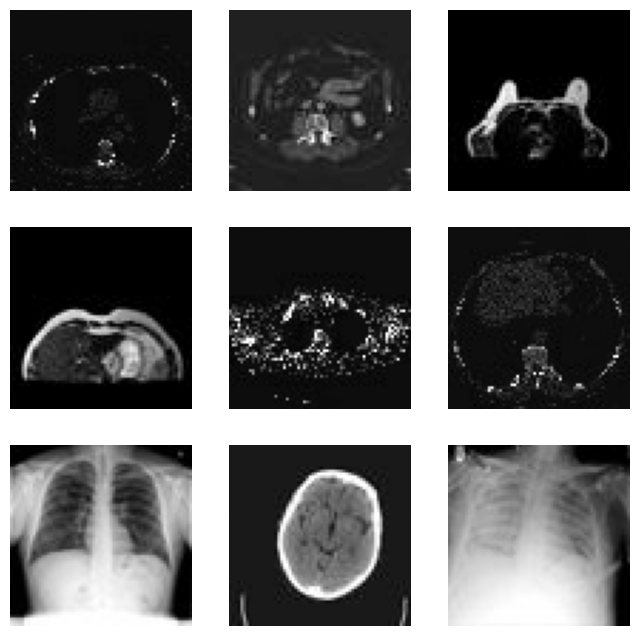

In [20]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

# **Autoencoder** Architecture

In [21]:
def build_simple_autoencoder(input_shape=(64, 64, 1)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2, padding="same")(x)   # 32x32

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same", name="encoded_layer")(x)  # 16x16

    # Decoder
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(encoded)  # 32x32
    x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)        # 64x64

    outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    model = models.Model(inputs, outputs, name="simple_autoencoder")
    return model


ae = build_simple_autoencoder()
ae.summary()

Model: "simple_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_layer (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

# AE Training and Reconstruction

In [22]:
EPOCHS = 10

ae.compile(optimizer='adam', loss='mse')

history_ae = ae.fit(
    train_ae,

    validation_data=val_ae,
    epochs=EPOCHS
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - loss: 0.0140 - val_loss: 0.0047
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0023 - val_loss: 0.0022


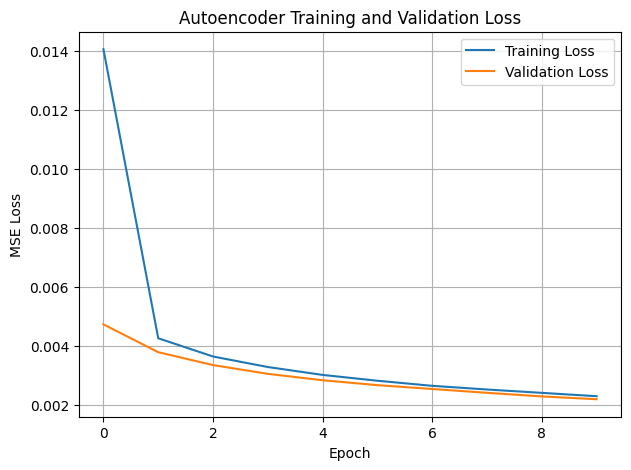

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 


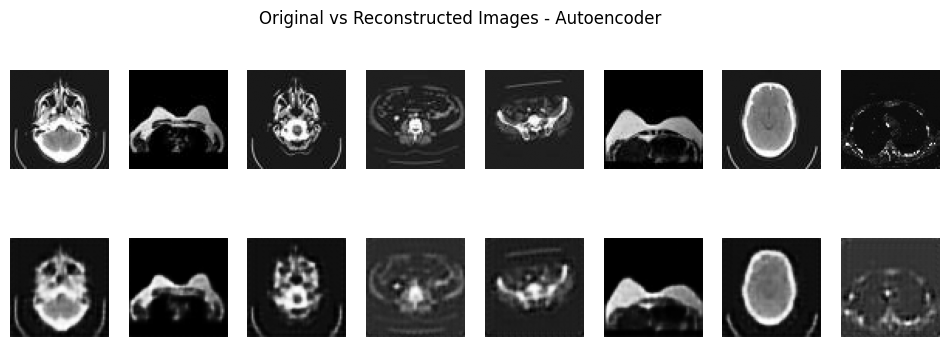

In [24]:
for images, _ in val_ae.take(1):
    reconstructed = ae.predict(images)

    plt.figure(figsize=(12, 4))

    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original")

        plt.subplot(2, 8, i + 9)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Reconstructed")

    plt.suptitle("Original vs Reconstructed Images - Autoencoder")
    plt.show()
    break

In [25]:
def normalize_with_label(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


train_labeled = train_ds.map(normalize_with_label).prefetch(tf.data.AUTOTUNE)
val_labeled = val_ds.map(normalize_with_label).prefetch(tf.data.AUTOTUNE)

In [26]:
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

#  Variational Autoencoder Architecture

In [27]:
LATENT_DIM = 2

# Encoder
encoder_inputs = layers.Input(shape=(64, 64, 1))

x = layers.Conv2D(16, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="vae_encoder")

# Decoder
decoder_inputs = layers.Input(shape=(LATENT_DIM,))

x = layers.Dense(16 * 16 * 32, activation="relu")(decoder_inputs)
x = layers.Reshape((16, 16, 32))(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)

decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(decoder_inputs, decoder_outputs, name="vae_decoder")

encoder.summary()
decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      4,640 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    524,352 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 529,412 (2.02 MB)

 Trainable params: 529,412 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,593 (150.75 KB)

 Trainable params: 38,593 (150.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

# **VAE** Training and Generation

In [29]:
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam())

history_vae = vae.fit(
    train_ae,
    epochs=10
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - kl_loss: 10.1537 - loss: 2317.4829 - reconstruction_loss: 2307.3281
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 11.0079 - loss: 2148.0818 - reconstruction_loss: 2137.0737
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 9.7986 - loss: 2101.1221 - reconstruction_loss: 2091.3235 
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 9.2974 - loss: 2091.0837 - reconstruction_loss: 2081.7856
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 9.0811 - loss: 2084.2292 - reconstruction_loss: 2075.1479
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 8.9376 - loss: 2079.5330 - reconstruction_loss: 2070.5955
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 8.8440 - loss: 2075.9900 - reconstruction_loss: 2067.1450
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - kl_loss: 8.7992 - loss: 2073.4480 - reconstruction_loss: 2064.6475
Epoch 9/10
369/369 ━

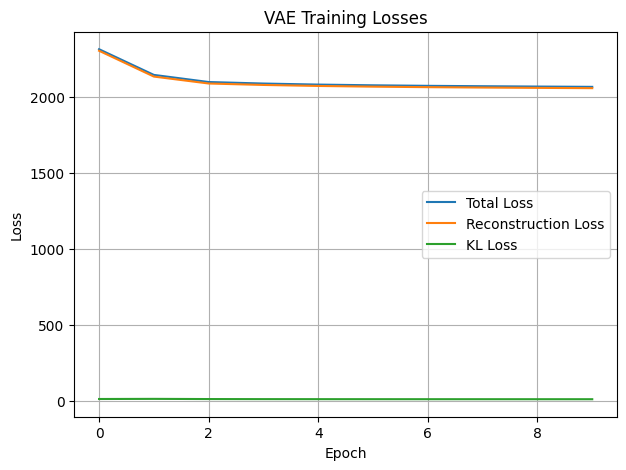

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(history_vae.history["loss"], label="Total Loss")
plt.plot(history_vae.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history_vae.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  


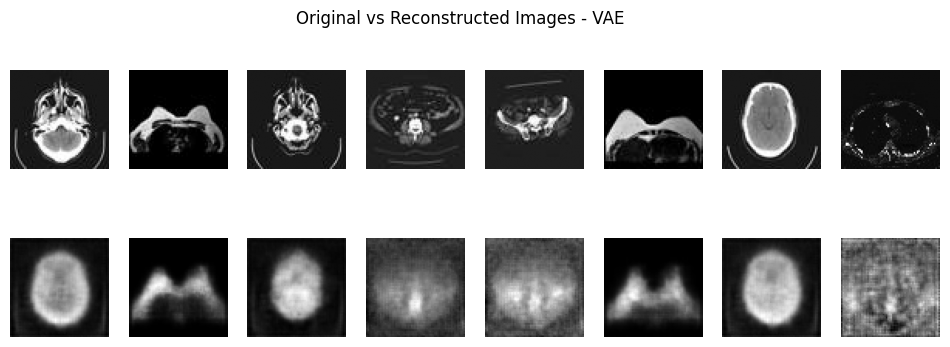

In [31]:
for images, _ in val_ae.take(1):
    reconstructed = vae.predict(images)

    plt.figure(figsize=(12, 4))

    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(2, 8, i + 9)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle("Original vs Reconstructed Images - VAE")
    plt.show()
    break

In [32]:
def calculate_mse(original, reconstructed):
    return tf.reduce_mean(tf.square(original - reconstructed)).numpy()


def calculate_mae(original, reconstructed):
    return tf.reduce_mean(tf.abs(original - reconstructed)).numpy()


for images, _ in val_ae.take(1):
    ae_reconstructed = ae.predict(images)
    vae_reconstructed = vae.predict(images)

    ae_mse = calculate_mse(images, ae_reconstructed)
    vae_mse = calculate_mse(images, vae_reconstructed)

    ae_mae = calculate_mae(images, ae_reconstructed)
    vae_mae = calculate_mae(images, vae_reconstructed)

print("AE MSE:", ae_mse)
print("VAE MSE:", vae_mse)
print("AE MAE:", ae_mae)
print("VAE MAE:", vae_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
AE MSE: 0.002353924
VAE MSE: 0.019795962
AE MAE: 0.026497874
VAE MAE: 0.08372411


# **Generated_Samples**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


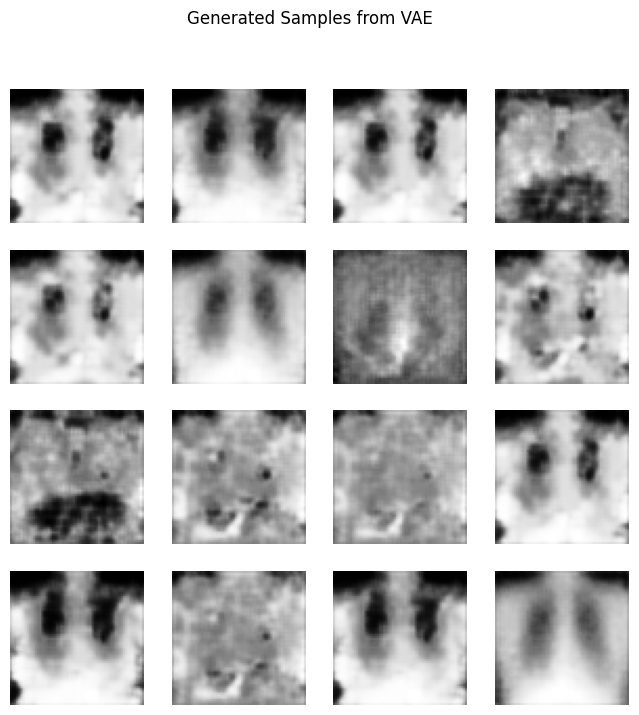

In [33]:
z_random = tf.random.normal(shape=(16, LATENT_DIM))
generated_images = decoder.predict(z_random)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Samples from VAE")
plt.show()

In [34]:
import numpy as np

z_points = []
labels_list = []

for images, labels in val_labeled.take(50):
    z_mean, z_log_var, z = encoder.predict(images, verbose=0)
    z_points.append(z_mean)
    labels_list.append(labels.numpy())

z_points = np.concatenate(z_points, axis=0)
labels_array = np.concatenate(labels_list, axis=0)

print("Latent points shape:", z_points.shape)
print("Labels shape:", labels_array.shape)

Latent points shape: (6400, 2)
Labels shape: (6400,)


# **Latent** Space Visualization

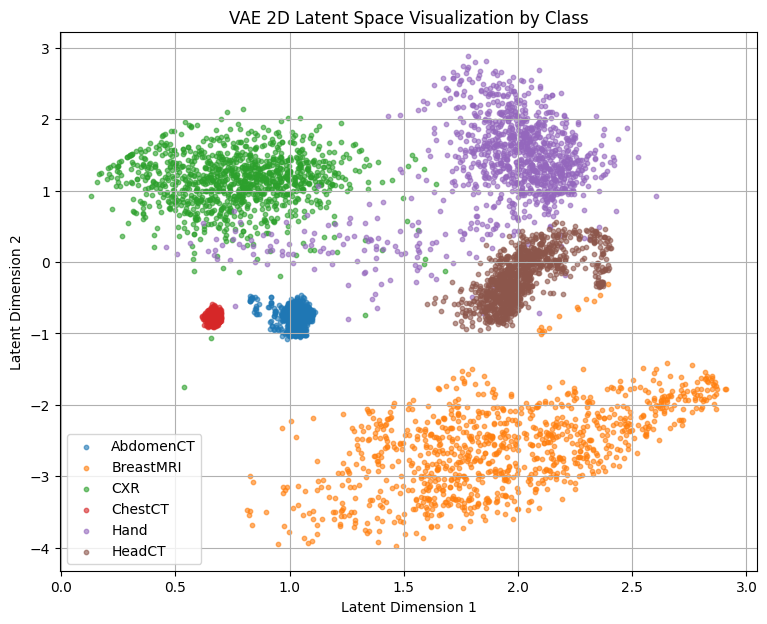

In [36]:
class_names = train_ds.class_names
plt.figure(figsize=(9, 7))

for class_id, class_name in enumerate(class_names):
    idx = labels_array == class_id
    plt.scatter(
        z_points[idx, 0],
        z_points[idx, 1],
        s=10,
        alpha=0.6,
        label=class_name
    )

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE 2D Latent Space Visualization by Class")
plt.legend()
plt.grid(True)
plt.show()

# **Denoising** Robustness Experiment

In [37]:
# Add noise function
def add_noise(images, noise_factor=0.3):
    noise = tf.random.normal(shape=tf.shape(images))
    noisy_images = images + noise_factor * noise
    return tf.clip_by_value(noisy_images, 0.0, 1.0)


# Create (noisy input → clean target) dataset
def add_noise_pair(x, y):
    noisy_x = add_noise(x)
    return noisy_x, y  # input = noisy, target = clean


train_denoise = (
    train_ae
    .map(add_noise_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_denoise = (
    val_ae
    .map(add_noise_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

In [38]:
denoising_ae = build_simple_autoencoder()

denoising_ae.compile(
    optimizer="adam",
    loss="mse"
)

history_denoise = denoising_ae.fit(
    train_denoise,
    validation_data=val_denoise,
    epochs=10
)

Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0166 - val_loss: 0.0079
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0073 - val_loss: 0.0068
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0060 - val_loss: 0.0059
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 9/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0057 - val_loss: 0.0056
Epoch 10/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0056 - val_loss: 0.0055


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step 


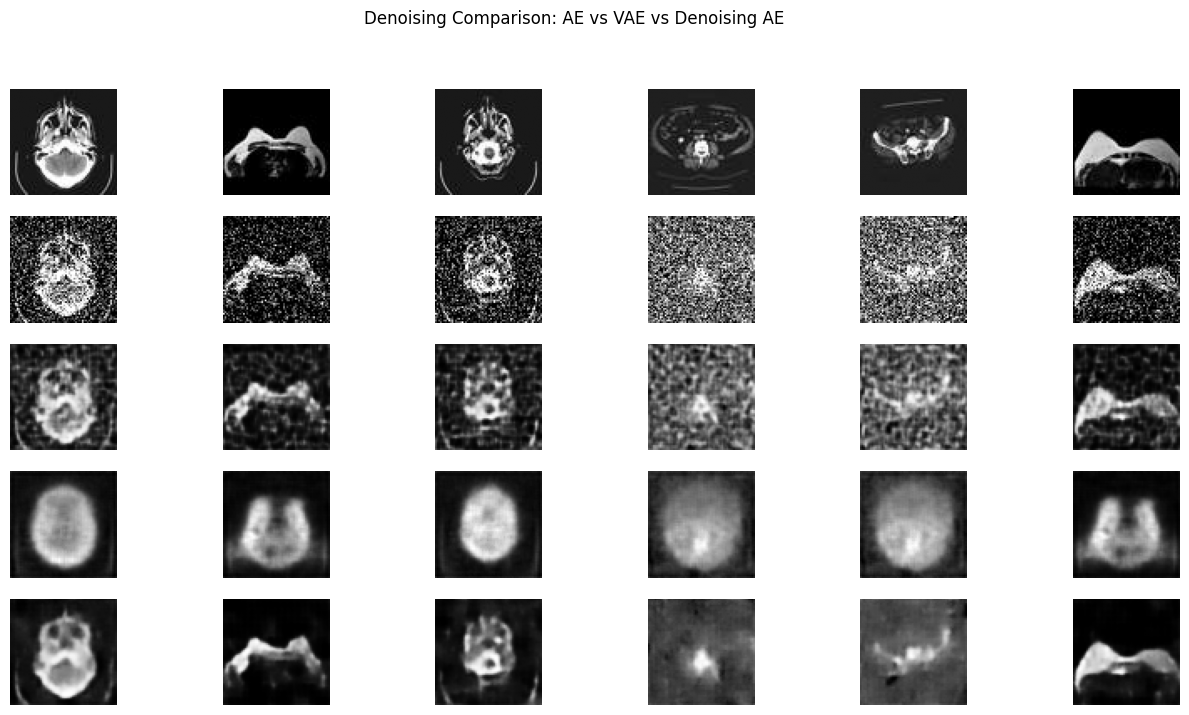

In [39]:
for clean_images, _ in val_ae.take(1):

    noisy_images = add_noise(clean_images)

    # Predictions
    ae_denoised = ae.predict(noisy_images)
    vae_denoised = vae.predict(noisy_images)
    dae_denoised = denoising_ae.predict(noisy_images)

    plt.figure(figsize=(16, 8))

    labels = ["Original", "Noisy", "AE", "VAE", "Denoising AE"]

    for i in range(6):

        # Original
        plt.subplot(5, 6, i + 1)
        plt.imshow(clean_images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[0])

        # Noisy
        plt.subplot(5, 6, i + 7)
        plt.imshow(noisy_images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[1])

        # AE
        plt.subplot(5, 6, i + 13)
        plt.imshow(ae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[2])

        # VAE
        plt.subplot(5, 6, i + 19)
        plt.imshow(vae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[3])

        # Denoising AE (trained on noise)
        plt.subplot(5, 6, i + 25)
        plt.imshow(dae_denoised[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel(labels[4])

    plt.suptitle("Denoising Comparison: AE vs VAE vs Denoising AE")
    plt.show()
    break

# **Train on All Regions**


In [40]:
from pathlib import Path

DATA_DIR = Path("/content/medical_mnist")

regions = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print("Regions:", regions)

Regions: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


In [41]:
def load_single_region(region_path, batch_size=128):
    ds = tf.keras.utils.image_dataset_from_directory(
        region_path,
        labels=None,
        image_size=(64, 64),
        color_mode="grayscale",
        batch_size=batch_size,
        shuffle=True
    )

    ds = ds.map(lambda x: (x / 255.0, x / 255.0))
    return ds

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model
def build_ae(latent_dim=32):
    encoder_inputs = layers.Input(shape=(64, 64, 1))

    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim)(x)

    encoder = Model(encoder_inputs, latent)

    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 64, activation='relu')(latent_inputs)
    x = layers.Reshape((16, 16, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    decoder = Model(latent_inputs, outputs)

    autoencoder = Model(encoder_inputs, decoder(encoder(encoder_inputs)))
    return autoencoder

In [48]:
class RegionSampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_vae(latent_dim=2):
    encoder_inputs = layers.Input(shape=(64, 64, 1))

    x = layers.Conv2D(16, 3, strides=2, activation="relu", padding="same")(encoder_inputs)
    x = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = RegionSampling()([z_mean, z_log_var])

    encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="region_vae_encoder")

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(16 * 16 * 32, activation="relu")(decoder_inputs)
    x = layers.Reshape((16, 16, 32))(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)
    decoder_outputs = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    decoder = models.Model(decoder_inputs, decoder_outputs, name="region_vae_decoder")

    vae = VAE(encoder, decoder)

    return encoder, decoder, vae

In [52]:
region_results = []

for region in regions:
    print(f"\n Training for: {region}")

    region_path = str(DATA_DIR / region)
    region_ds = load_single_region(region_path)

    # AE
    print("Training AE...")
    ae_model = build_ae()
    ae_model.compile(optimizer='adam', loss='mse')
    ae_model.fit(region_ds, epochs=10, verbose=1)

    # VAE
    print("Training VAE...")
    encoder, decoder, vae_model = build_vae(latent_dim=2)
    vae_model.compile(optimizer='adam')
    vae_model.fit(region_ds, epochs=10, verbose=1)

    # Evaluate
    for images, _ in region_ds.take(1):
        ae_out = ae_model.predict(images, verbose=0)
        vae_out = vae_model.predict(images, verbose=0)

        ae_mse = tf.reduce_mean(tf.square(images - ae_out)).numpy()
        vae_mse = tf.reduce_mean(tf.square(images - vae_out)).numpy()

    region_results.append({
        "Region": region,
        "AE_MSE": ae_mse,
        "VAE_MSE": vae_mse
    })

print("Done!")


 Training for: AbdomenCT
Found 10000 files.
Training AE...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0091
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0063
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0045
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0036
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0029
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0025
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0022
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0020
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0019
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0017
Training VAE...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - kl_loss: 0.2153 - loss: 2801.1189 - reconstruction_loss: 2800.9041
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - kl_loss: 0.0265 - loss: 2791.5317 - reconstruction_loss: 2791.5061
Epoch 3/10
79/79 ━━━━━━

In [53]:
import pandas as pd

df = pd.DataFrame(region_results)
df

,Region,AE_MSE,VAE_MSE
0,AbdomenCT,0.001665,0.006899
1,BreastMRI,0.004472,0.018550
2,CXR,0.004800,0.030468
3,ChestCT,0.002087,0.003261
4,Hand,0.005301,0.025906
5,HeadCT,0.009322,0.028231


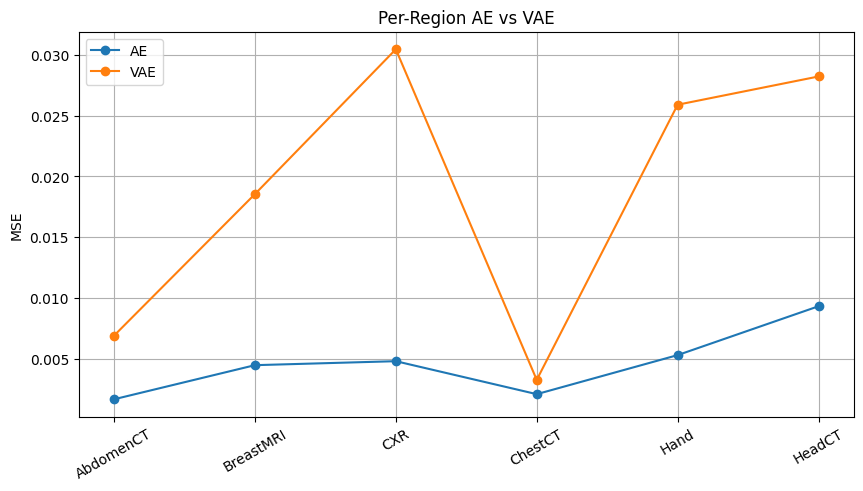

In [57]:
plt.figure(figsize=(10,5))

plt.plot(df["Region"], df["AE_MSE"], marker='o', label="AE")
plt.plot(df["Region"], df["VAE_MSE"], marker='o', label="VAE")

plt.xticks(rotation=30)
plt.title("Per-Region AE vs VAE")
plt.ylabel("MSE")
plt.legend()
plt.grid()

plt.show()

Final Insights:

The Autoencoder achieved better reconstruction quality and produced sharper outputs compared with the VAE. The VAE reconstructions were smoother because of the probabilistic latent space, but the VAE was able to generate new samples from random latent vectors. The latent space visualization showed partial clustering between the six medical image classes, indicating that the VAE learned meaningful low-dimensional representations. For denoising, the Denoising Autoencoder gave the best results because it was trained using noisy images as input and clean images as targets.